# GO proposal: Hunting for pre-MS star oscillators

This notebook is used to prepare and launch the simulations related to the paper the detectability of p-mode oscillations in pre-main sequence stars, in collaboration with Johannes Jørgensen and Konstanze Zwintz (INTA).

- Author: Nicholas Jannsen
- Last check: 2026-01-27
- PlatoSim version: `3.7.0-191-g42fc64d4`

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
# Built-in
import os
import sys
import glob

# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# PlatoSim libraries
import platosim.plot      as pt
import platosim.utilities as ut
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [3]:
# Set global paths
hdir = ut.getHomeDir('inputfiles/data_picsim')
wdir = ut.getWorkDir('go_prems')
idir = wdir / 'input'
fdir = wdir / 'figures'
sdir = wdir / 'simulations'

---
## 1. Stellar catalogue
---

In [5]:
# Load PLATO-CS catalogue
df = pd.read_feather(hdir / 'PlatoCS_NCAM_LOPS2.ftr')

### 1.1. Catalogue of **all** pre-MS stars

In [13]:
# Filename to load and save files
filename = 'all_v0'

In [14]:
# Load Pre-MS catalogue
dt = pd.read_csv(idir / f'table_targets_{filename}.csv')
dt.head()

,ID,gaiaDR3,Pmag,Gmag,ra,dec
0,1,2885659097345755648,14.841428,15.018138,94.514026,-34.544374
1,2,2886290079581074432,15.142609,15.319207,93.342170,-35.022312
2,3,2890046080021476352,14.823780,14.999045,91.413240,-32.674862
3,4,2895540751943528960,16.155236,16.329124,97.784416,-29.021455
4,5,2895546146422412800,15.847063,16.032137,97.996331,-28.911655


<IPython.core.display.Javascript object>


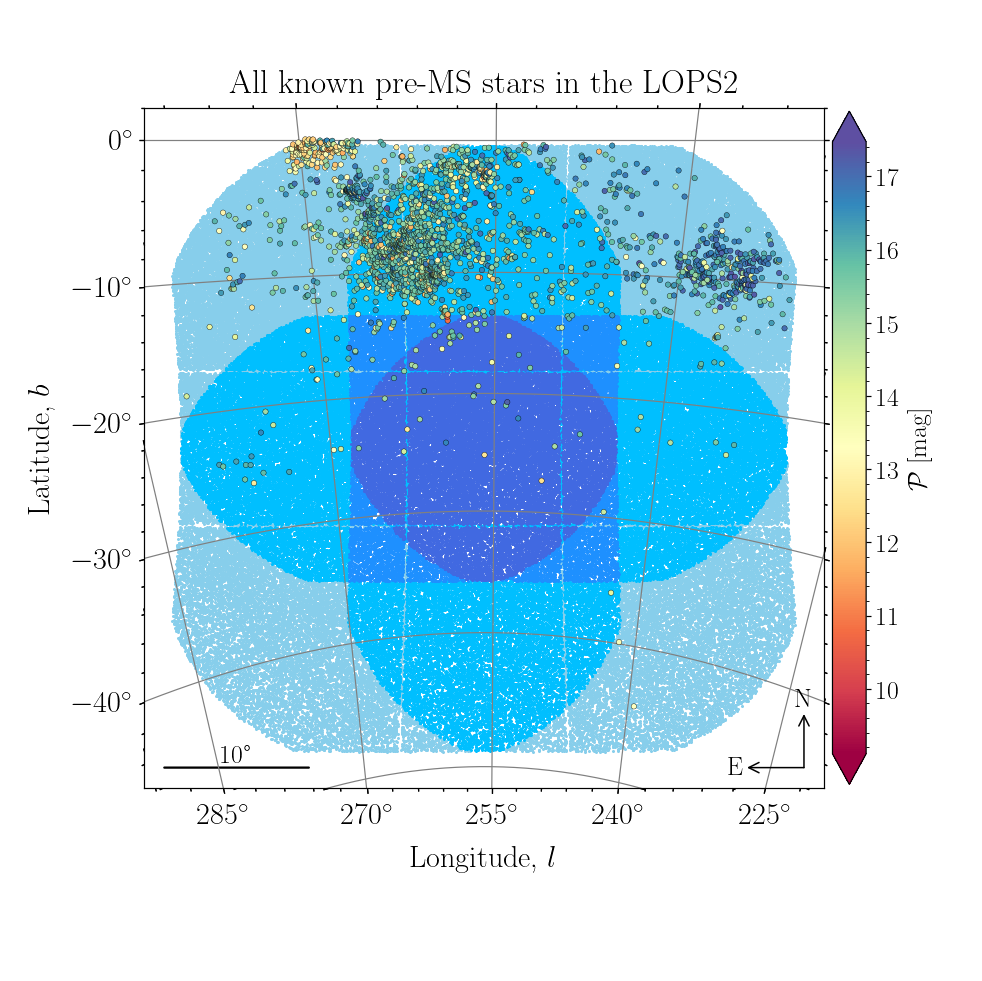

In [17]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=29,
                          raStars=dt.ra, decStars=dt.dec, c=dt.Pmag, ncamStars=True,
                          clabel=r'$\mathcal{P}$ [mag]', s=50, lw=0.25, figsize=(9,9),
                         title='All known pre-MS stars in the LOPS2')
fig.savefig(fdir / f'starcat_sky_targets_{filename}.png', bbox_inches='tight', dpi=200)

In [31]:
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / f'starcat_{filename}_targets.ftr')

In [32]:
# Create contaminant catalogue
dc = ut.getContaminants(dt, df, column='gaiaDR3')
dc.to_feather(idir / f'starcat_{filename}_contaminants.ftr')

100%|██████████████████████████████████████████████████| 2452/2452 [04:39<00:00,  8.77it/s]                                                                                                                        


### 1.2. Catalogue of **legacy** pre-MS stars

In [6]:
# Filename to load and save files
filename = 'legacy_v0'

In [7]:
# Load Pre-MS catalogue
dt = pd.read_csv(idir / f'table_targets_{filename}.csv')
dt

,ID,gaiaDR3,Pmag,Gmag,ra,dec
0,1,5293615675576469376,10.874806,11.867610,115.013258,-58.887288
1,2,5515139604690479360,11.138553,12.132744,125.378550,-48.887964
2,3,2891878897185918464,11.453030,12.203967,97.000541,-34.069660
3,4,5507641553862411904,10.655000,12.268989,112.217191,-46.971553
4,5,5536950621147994112,11.433082,12.340618,114.810718,-40.245183
...,...,...,...,...,...,...
287,288,5519247693671723392,15.216618,15.982557,122.256516,-47.285203
288,289,5331168808033871744,13.221317,15.984504,133.371046,-45.929266
289,290,5539440430869778304,14.324331,15.984816,124.044640,-41.350379
290,291,5519267622320735104,15.266125,15.987767,122.482517,-47.261784


<IPython.core.display.Javascript object>


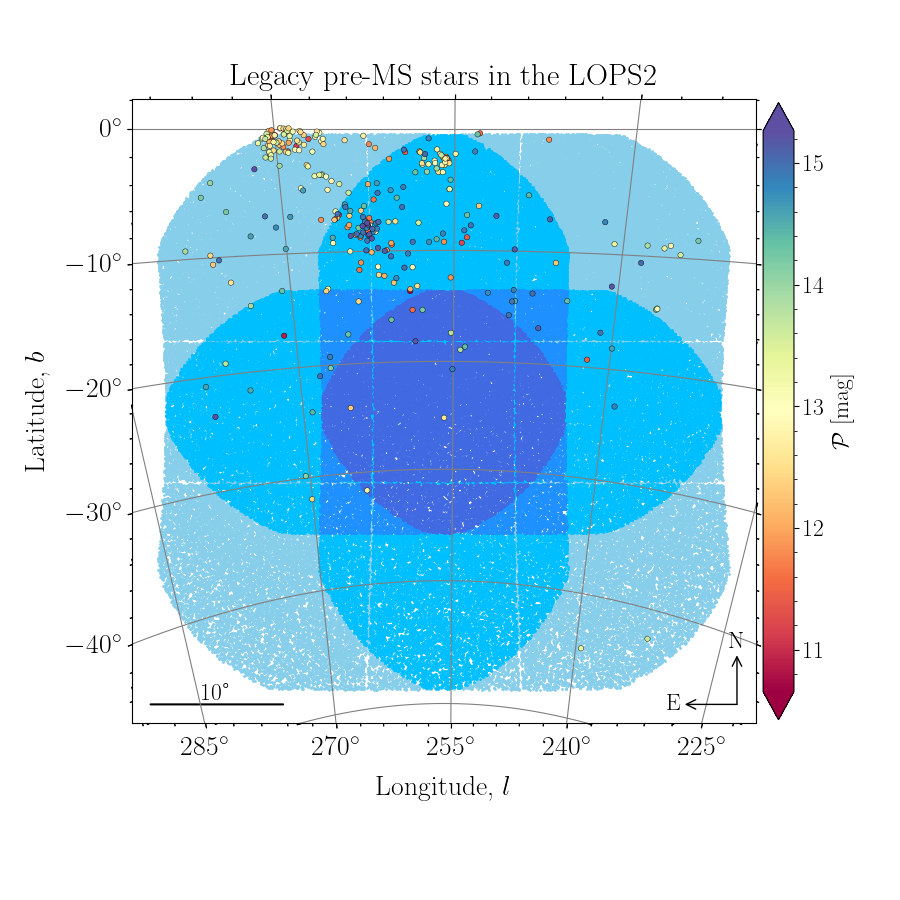

In [54]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=29,
                          raStars=dt.ra, decStars=dt.dec, c=dt.Pmag, ncamStars=True,
                          clabel=r'$\mathcal{P}$ [mag]', s=60, lw=0.3, figsize=(9,9),
                          title='Legacy pre-MS stars in the LOPS2')
fig.savefig(fdir / f'starcat_sky_targets_{filename}.png', bbox_inches='tight', dpi=200)

In [55]:
dx = dt.loc[:20]
dx

,ID,gaiaDR3,Pmag,Gmag,ra,dec
0,1,5293615675576469376,10.874806,11.867610,115.013258,-58.887288
1,2,5515139604690479360,11.138553,12.132744,125.378550,-48.887964
2,3,2891878897185918464,11.453030,12.203967,97.000541,-34.069660
3,4,5507641553862411904,10.655000,12.268989,112.217191,-46.971553
4,5,5536950621147994112,11.433082,12.340618,114.810718,-40.245183
5,6,5519267038205288832,11.846169,12.464344,122.399510,-47.314536
6,7,5523341656495999360,11.760631,12.524666,129.574006,-43.217503
7,8,5519287958978776576,11.742122,12.559176,122.375441,-46.965500
8,9,5322638040913559808,11.805289,12.578450,126.253645,-50.394464
9,10,5519831598758951808,11.621406,12.589271,124.349913,-45.648991


<IPython.core.display.Javascript object>


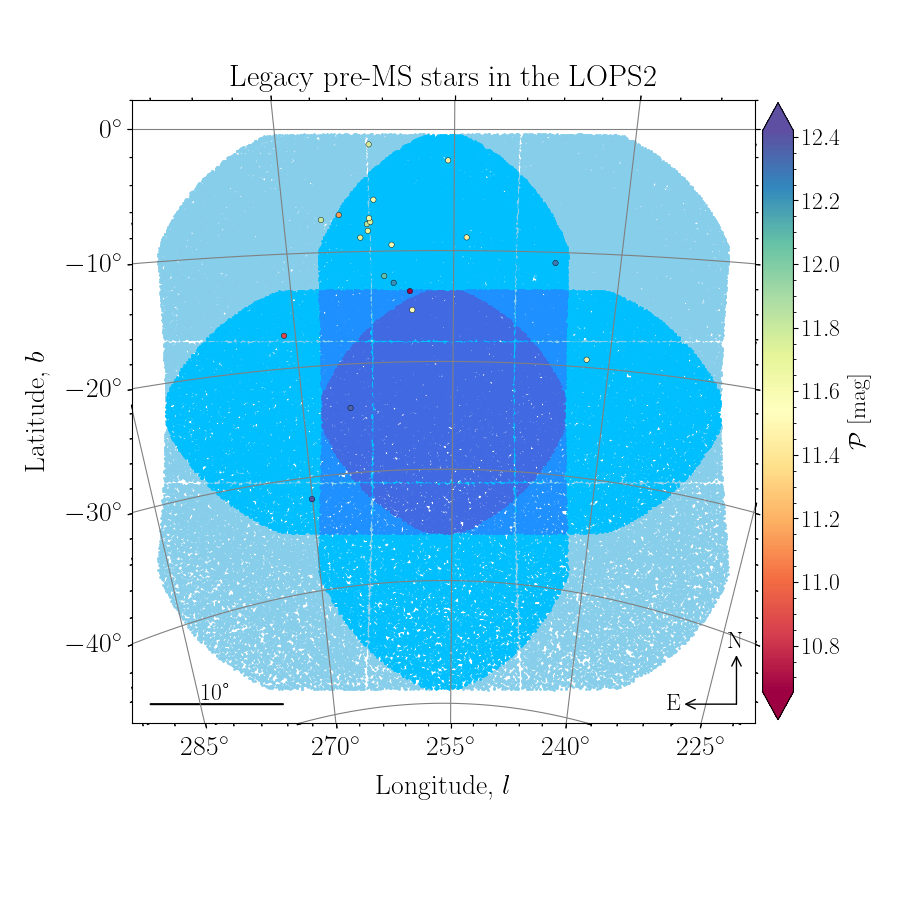

In [57]:
# Plot target in Galactic projection
dx = dt.loc[:20]
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=29,
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, ncamStars=True,
    clabel=r'$\mathcal{P}$ [mag]', s=60, lw=0.3, figsize=(9,9),
    title='Legacy pre-MS stars in the LOPS2'
)

In [36]:
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / f'starcat_{filename}_targets.ftr')

In [37]:
# Create contaminant catalogue
dc = ut.getContaminants(dt, df, column='gaiaDR3')
dc.to_feather(idir / f'starcat_{filename}_contaminants.ftr')

100%|██████████████████████████████████████████████████| 292/292 [00:33<00:00,  8.60it/s]                                                                                                                          


### *Troubleshoot missing stars*

In [134]:
# def missing_elements(L):
#     start, end = L[0], L[-1]
#     return sorted(set(range(start, end + 1)).difference(L))

# import glob
# import natsort
# folder = sdir / 'legacy/mission/lightcurve/*'
# files = natsort.natsorted(glob.glob(str(folder)))

# # Get IDs of simulated stars
# IDs = [int(files[i][-13:-4])-1 for i in range(len(files))]

# # Find missing star IDs
# ids = missing_elements(IDs)
# dx = dt.loc[ids]
# ar = np.array(ids) + 1
# ar.tolist()

<IPython.core.display.Javascript object>


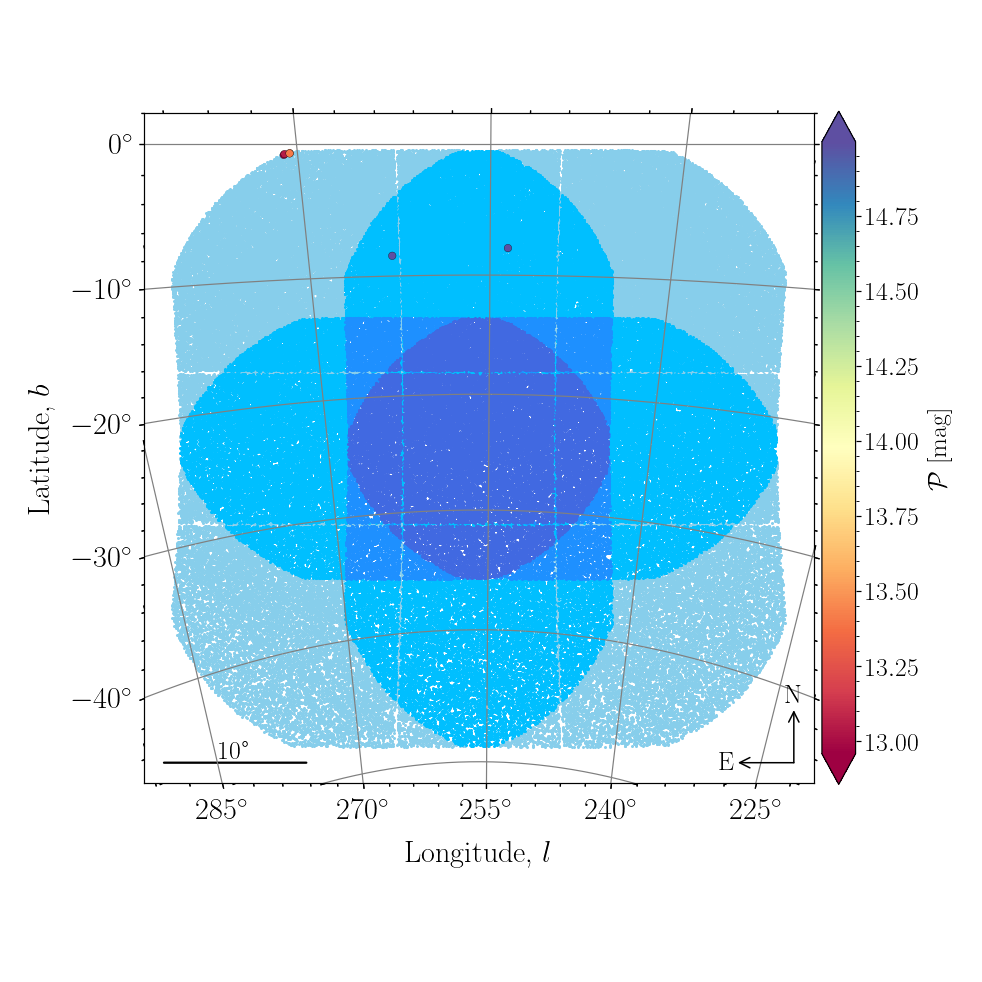

In [22]:
# MISSING STARS ROUND 2: 
# It was discovered that the rOA = 18.89deg in the YAML did not allow for all stars in group 1 to be detected
# The new FOV match the PIC and is 19.89 deg when accounting for distortion.
#----------------------
# Within  FOV: 96, 110, 138, 211, 256 (?)
# Outside FOV: 54, 108, 112, 113, 165, 222, 236, 271
# Missing sims: 79 (not found by platonium!), 273 (no varsource but is found by platonium)
ids_good = np.array([96, 110, 138, 211, 256, 263]).T-1
ids_bad  = np.array([54, 108, 112, 113, 165, 222, 236, 271]).T-1
ids_miss = np.array([79, 273])
dx = dt.loc[ids_good]
# dx = dt.loc[271-1]
# Let's first plot the target
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=29, showGroups=False,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, ncamStars=True,
                          clabel=r'$\mathcal{P}$ [mag]', s=100, lw=0.2, figsize=(9,9))

---
## 2. Transform variable templates
---

In [646]:
# Select star
ID = 20
star3 = f'{ID}'.zfill(3)
star9 = f'{ID}'.zfill(9)
ifile = sdir / f'legacy/templates/varsource_{star3}.csv'
ofile = sdir / f'legacy/varsource/varsource_{star9}.txt'
df = pd.read_csv(ifile, names=['time', 'dmag'], sep=',', skiprows=1)
data = np.transpose([df.time, df.dmag])
np.savetxt(ofile, data, fmt=['%.2f', '%.12f'])

In [647]:
# Load new variable template and plot
filename = sdir / f'legacy/varsource/varsource_{star9}.txt'
dv = pd.read_csv(filename, sep=' ', names=['time', 'dmag'])
dv['flux'] = ut.fromMagToFlux(dv.dmag)

<IPython.core.display.Javascript object>


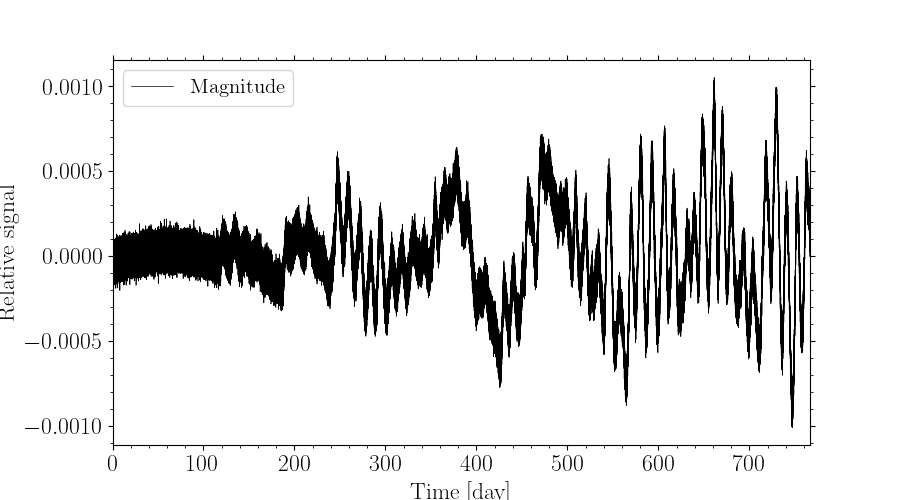

In [648]:
# Plot light curve
time = dv.time/86400
fig = plt.figure(figsize=(9,5))
plt.plot(time, dv.dmag, 'k-', lw=0.5, label='Magnitude')
# plt.plot(time, dv.flux-1, 'b-', lw=0.5, label='Flux')
plt.xlabel('Time [day]')
plt.ylabel('Relative signal')
plt.legend()
plt.xlim(time.iloc[0], time.iloc[-1]);

<IPython.core.display.Javascript object>


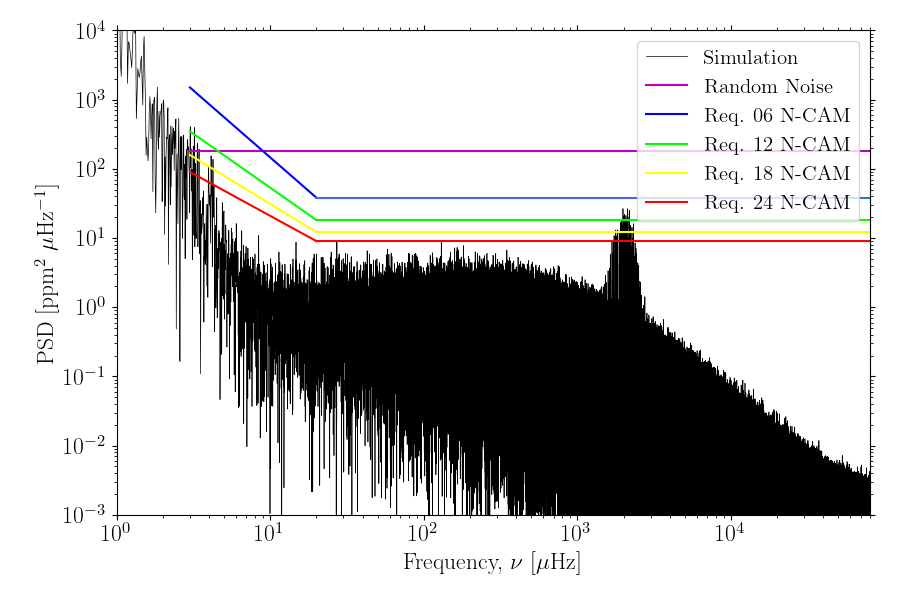

In [649]:
# Plot PSD
nuquist = 1/(2 * dv.time.diff().iloc[1] / 1e6)
fig, ax = pt.plotPeriodogram(dv)
ax.set_xlim(1, nuquist)
ax.set_ylim(1e-3, 1e4);

---
## 3. Test post-processing
---

In [11]:
# Choose star ID
ID = 2
star = f'{ID}'.zfill(9)
idir = sdir / f'legacy/camera/{star}'
odir = sdir / 'legacy/mission'
lcs = LightCurve(idir, mode='multi')
fdir = wdir / 'simulations/legacy/figures'

In [12]:
# Create table with simulation statistics
dt = lcs.stat_sim_table(ofile=odir/f'{star}.tab', clean=False)
dt.head()

,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR,NSR
0,2,5.515140e+18,125.37855,-48.887964,11.138553,1,1,1,2,2625.243795,3862.848325,11.476178,-12.948730,-48.554388,7,0.007215,0.003068
1,2,5.515140e+18,125.37855,-48.887964,11.138553,1,1,5,2,2625.329994,3862.935156,11.476422,-12.947167,-48.555940,7,0.007491,0.003104
2,2,5.515140e+18,125.37855,-48.887964,11.138553,1,2,1,2,2633.858094,3852.284425,11.520417,-13.138880,-48.709446,7,0.004391,0.003085
3,2,5.515140e+18,125.37855,-48.887964,11.138553,1,2,5,2,2633.944313,3852.371275,11.520660,-13.137317,-48.710998,7,0.004802,0.003056
4,2,5.515140e+18,125.37855,-48.887964,11.138553,1,3,1,2,2630.381144,3854.373748,11.504811,-13.101273,-48.646861,7,0.006536,0.003081


<IPython.core.display.Javascript object>


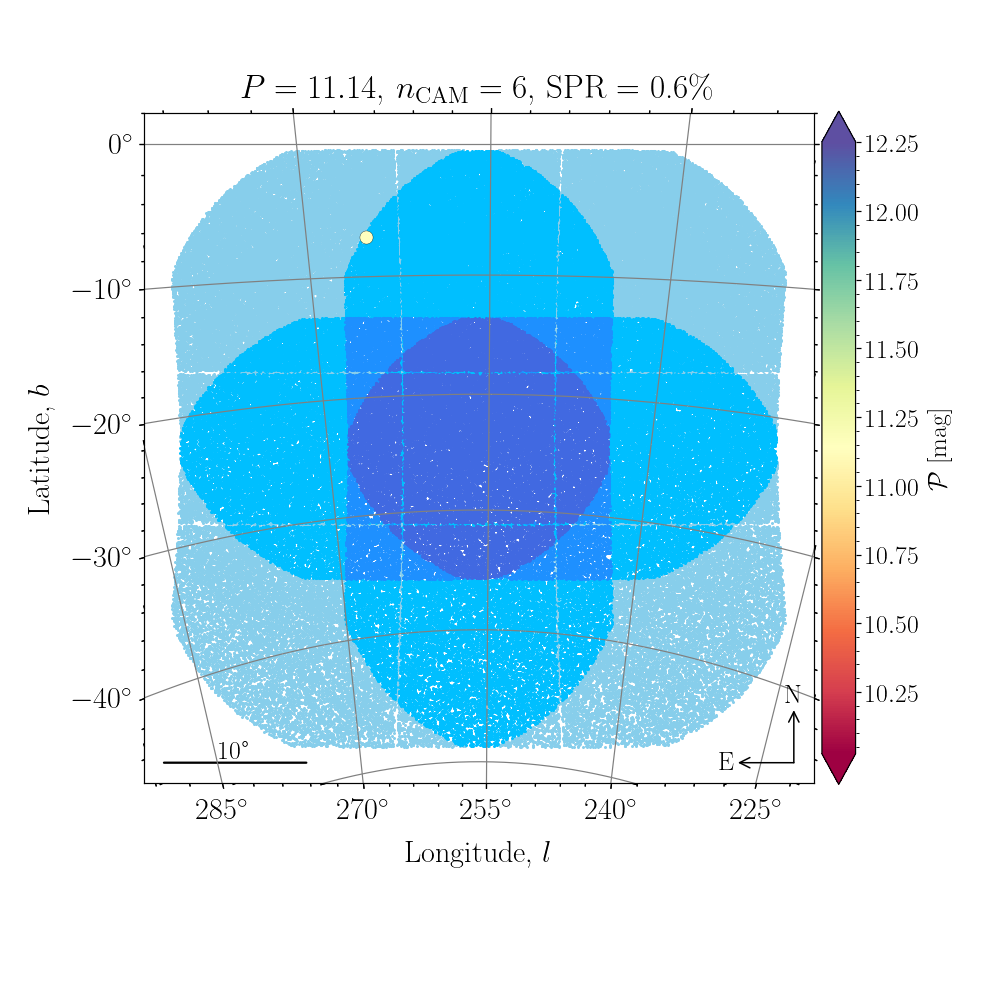

In [13]:
# Plot the target in sky
dx = dt.iloc[ID-1]
Pmag = dt.mag.iloc[0]
ncam = dt.shape[0]/8
SPR  = dt.SPR.mean()*100
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=29,
    raStars=dx.ra, decStars=dx.dec, c=dx.mag, ncamStars=True,
    clabel=r'$\mathcal{P}$ [mag]', s=300, lw=0.2, figsize=(9,9),
    title=rf'$P={Pmag:.2f}$, '+r'$n_{\rm CAM}='+f'{ncam:.0f}$, SPR = {SPR:.1f}\%'
)
# fig.savefig(fdir / f'starcat_sky_{star}.png', bbox_inches='tight', dpi=200)

### 2.1. Test camera-level reduction

In [653]:
# # Load files 
# files = lcs.files(suffix='ftr')
# files[0]

In [654]:
# # Load a single mission quarter light curve
# lc = LightCurve(files[0], mode='single')

In [655]:
# Show a quarter light curve
# lc.plot(flux_unit='e/s', median_filter=1, input_model=False, figsize=(9,4));

In [656]:
# # Test detrending
# df = lc.detrend(model='poly', replace=True, plot=True)

In [657]:
# Test outlier rejection (due to photon noise and cosmic ray hits)
# df = lc.clip(model='wotan', sigma_lower=4, sigma_upper=4, flux_unit='ppt', plot=True, replace=True)
# df = df.dropna()

In [658]:
# Test flux error creation
# df = lc.flux_error(flux_unit='ppt', plot=True)

#### Noise budget in time domain

In [659]:
# # Compute NSR camera level [ppm 25s]
# NSR_25s = lc.get_nsr(binhour=0)
# NSR_25s

In [660]:
# # Compute NSR camera level [ppm 50s]
# NSR_50s = lc.get_nsr(binhour=50/3600)
# NSR_50s

In [661]:
# # Compute NSR camera level [ppm 1h]
# NSR_1h = lc.get_nsr(binhour=1)
# NSR_1h

In [662]:
# # Compare NSR value to previous simulations
# dc = pd.read_feather(wdir / '../mocka/simulations/nsr/nsr_per_camera_BOL.ftr')
# # Plot all NSR per camera
# dc = dc[dc.SPR < 0.06]
# fig, ax = pt.plotNSRvsMagnitude(dc, column='rOA')
# ax.plot(dt.mag.iloc[0], NSR_1h, '*', c='yellow', mec='k', ms=15);
# ax.set_ylim(3e1, 2e4);

#### Noise budget in Fourier domain

In [663]:
# dt = 25e-6 # [Ms]
# sigma = NSR_25s  # [ppm]
# PSD_mean = dt*sigma**2 
# ASD_mean = np.sqrt(np.pi/2*dt*sigma**2/2)
# PSD_mean, ASD_mean, 50**2

In [664]:
# # Plot PSD
# fig, ax = pt.plotPeriodogram(df, dv, noise_level=PSD_mean)
# ax.set_xlim(1, 3e4)
# ax.set_ylim(1e-3, 1e4);

### 2.2. Test mission-level redcution

<IPython.core.display.Javascript object>


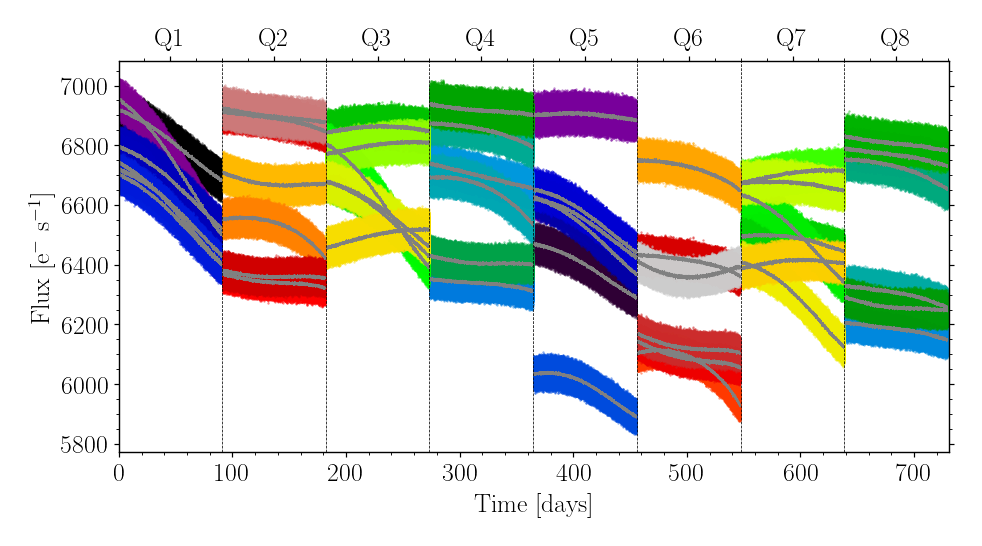

In [14]:
# Show all light curves
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.5, figsize=(9,5));
# fig.savefig(fdir / f'camera_lightcurves_{star}.png', bbox_inches='tight', dpi=200)

In [15]:
# Post-processing into final light curve
lc = lcs.merge(
    suffix='ftr',
    flux_detrend='poly', 
    poly_degree=False,
    flux_group_mean=True,
    binsize=150,
    clip_sigma=3,
    flux_offset=True,
    flux_error=False,
    ofile=odir/f'{star}.ftr'
)

Processing star ID 000000002
-------------------------------------------------------
Merging 48 light curves


100%|██████████████████████████████████████████████████| 48/48 [00:24<00:00,  1.97it/s]                                                                                                                     


Sorting data after timings
Averaging data from same camera group
Binning data per 150s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Saving light curve
Total execution time: 0:01:00.287307 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


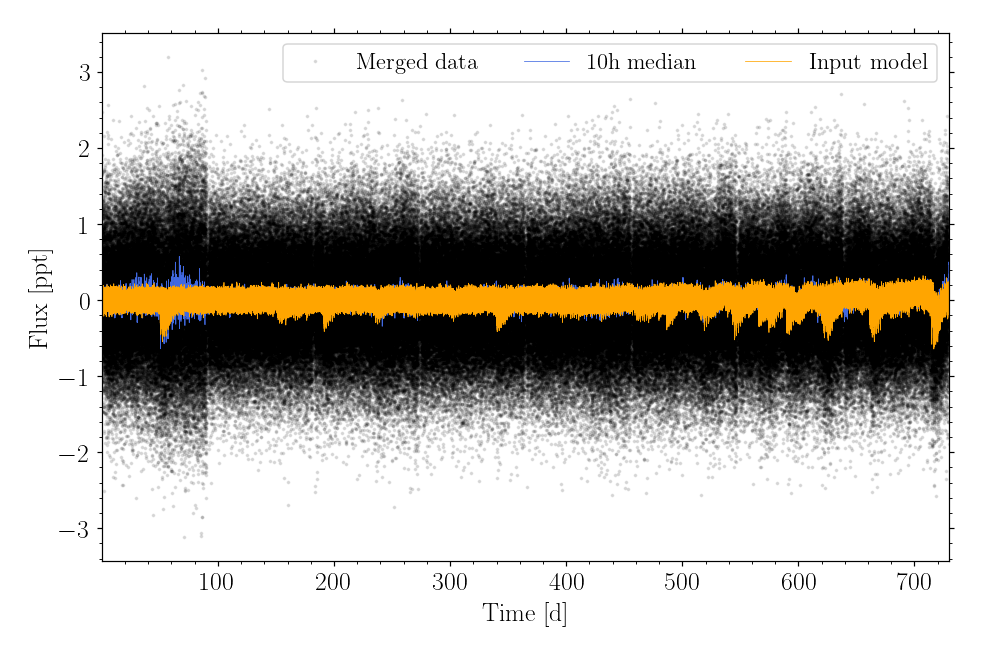

In [16]:
# Show result
fig, ax = lc.plot(input_model=True, flux_unit='ppt', flux_error=False, median_filter=10, alpha=0.1, figsize=(9,6));
fig.savefig(fdir / f'mission_lightcurve_{star}.png', bbox_inches='tight', dpi=200)

#### Noise budget in time domain

In [668]:
# Compare NSR value to previous simulations
dc = pd.read_feather(wdir / '../mocka/simulations/nsr/nsr_per_star_BOL.ftr')

In [669]:
# Compute NSR camera level [ppm 150s]
NSR_150s = lc.get_nsr(binhour=0)
NSR_150s

804.3864999824299

In [670]:
# Compute NSR camera level [ppm 1h]
NSR_1h = lc.get_nsr(binhour=1)
NSR_1h

154.93726243211697

<IPython.core.display.Javascript object>


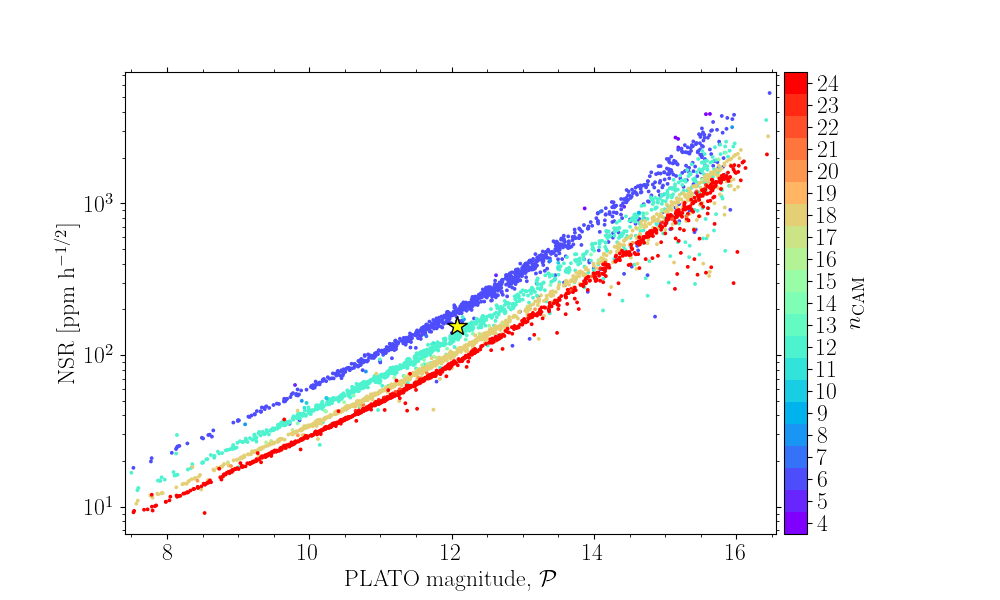

In [671]:
# Show mission level NSR vs. Pmag
fig, ax = pt.plotNSRvsMagnitude(dc, column='ncam')
ax.plot(dt.mag.iloc[0], NSR_1h, '*', c='yellow', mec='k', ms=15);
fig.savefig(fdir / f'nsr_mission_level_{star}.png', bbox_inches='tight', dpi=200)

#### Noise budget in Fourier domain

In [672]:
# Load variable template
dv = lc.varsource()
df = lc.data().dropna()

In [673]:
# Compute mean noise
dt = 150e-6 # [Ms]
sigma = NSR_150s  # [ppm]
PSD_mean = dt*sigma**2 
ASD_mean = np.sqrt(np.pi/2*dt*sigma**2/2)
PSD_mean, ASD_mean

(97.05564620309754, 8.730826208055301)

<IPython.core.display.Javascript object>


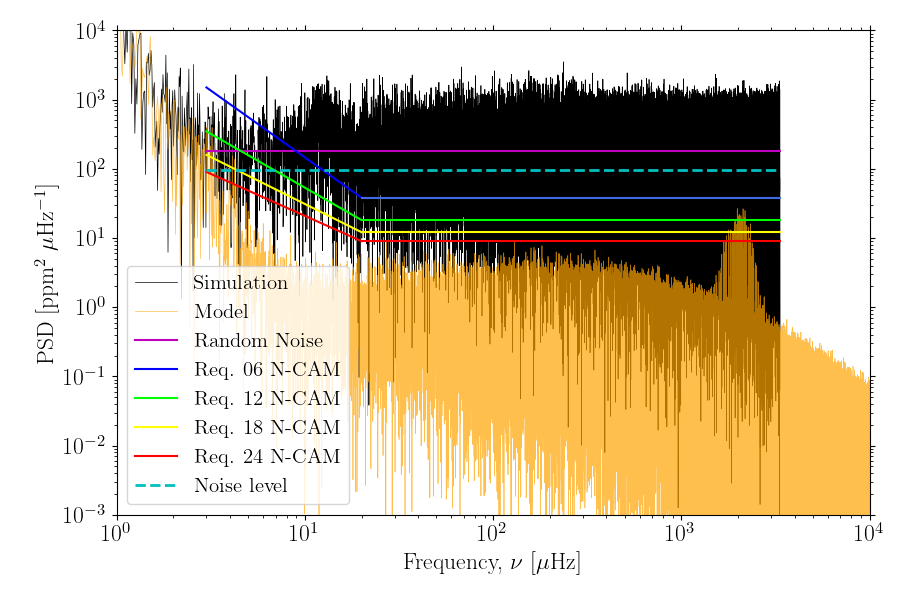

In [674]:
# Plot PSD
fig, ax = pt.plotPeriodogram(df, dv, noise_level=PSD_mean)
ax.set_xlim(1, 1e4) 
ax.set_ylim(1e-3, 1e4);
fig.savefig(fdir / f'psd_io_{star}.png', bbox_inches='tight', dpi=200)

---
## 4. Check mission-level light curves (VSC)
---

In [11]:
# # Select star
# ID = 2
# star3 = f'{ID}'.zfill(3)
# star9 = f'{ID}'.zfill(9)
# xdir = sdir / 'legacy'

# # Load light curve object
# filename = xdir / f'mission/lightcurve/lc_{star9}.ftr'
# lc = LightCurve(filename, mode="final")
# df = lc.data()

# # Load variable template
# filename = xdir / f'varsource/varsource_{star3}.csv'
# dv = pd.read_csv(filename, skiprows=1, names=['time', 'dmag'])
# dv['flux'] = ut.fromMagToFlux(dv.dmag)

In [12]:
# # Plot the fully reduced light curve
# fig, ax = lc.plot(flux_unit='norm', median_filter=24)
# ax.plot(dv.time/86400, dv.flux, '-', c='orange');

In [13]:
# # Plot PSD
# fig, ax = pt.plotPeriodogram(df, dv)
# ax.set_xlim(1e-1, 1e4)
# ax.set_ylim(1e-3, 1e4);

In [14]:
# # Plot target in sky
# dx = dt.iloc[ID-1]
# fig, ax = pt.plotPlatoFOV(
#     'LOPS2', system='galactic', fovSize=29,
#     raStars=dx.ra, decStars=dx.dec, c=dx.mag, ncamStars=True,
#     clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.2, figsize=(9,9)
# )

---
## Check of Sun-like star from PlatoSim paper
---

In [48]:
df = pd.read_feather(sdir / 'lc_final.ftr')
# df.flux += 1
lc = LightCurve(df, mode='reduced')
# lc.plot(flux_unit='ppt', alpha=0.1)
df = lc.bin(binsize=25, time_unit='s')
df.flux += 1

In [43]:
dv = pd.read_feather(sdir / 'varsource_000000001_components.ftr')
dv['flux'] = dv.comb/1e6 + 1 #* (dv.gran/1e6 + 1)
dv

,time,gran,puls,tran,occu,beam,elli,comb,spot,flux
0,0.0,-30.227651,3.786619,0.0,0.0,0.000187,-2.756385e-07,-26.441032,0.0,0.999974
1,25.0,-26.257797,6.413521,0.0,0.0,0.000187,-2.756395e-07,-19.844276,0.0,0.999980
2,50.0,-11.255772,7.667452,0.0,0.0,0.000187,-2.756405e-07,-3.588321,0.0,0.999996
3,75.0,-5.799542,7.407067,0.0,0.0,0.000187,-2.756414e-07,1.607525,0.0,1.000002
4,100.0,-2.566221,5.239296,0.0,0.0,0.000187,-2.756424e-07,2.673075,0.0,1.000003
...,...,...,...,...,...,...,...,...,...,...
4043515,101087875.0,-56.715144,0.385987,0.0,0.0,-0.000977,1.717017e-07,-56.329157,0.0,0.999944
4043516,101087900.0,-34.388688,-4.418898,0.0,0.0,-0.000977,1.717040e-07,-38.807586,0.0,0.999961
4043517,101087925.0,-18.143076,-7.809382,0.0,0.0,-0.000977,1.717063e-07,-25.952458,0.0,0.999974
4043518,101087950.0,-8.157267,-9.015438,0.0,0.0,-0.000977,1.717086e-07,-17.172704,0.0,0.999983


In [49]:
df

,time,flux
0,1.250000e+01,0.999628
1,3.750000e+01,0.999956
2,6.250000e+01,1.000331
3,8.749999e+01,1.000486
4,1.125000e+02,0.999471
...,...,...
4036603,1.009151e+08,1.002006
4036604,1.009151e+08,0.999975
4036605,1.009151e+08,1.000101
4036606,1.009152e+08,1.000029


<IPython.core.display.Javascript object>


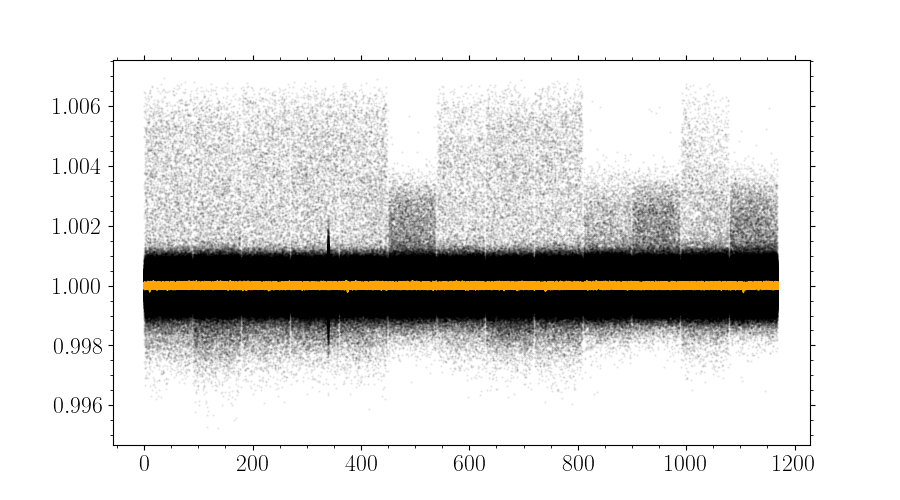

In [53]:
plt.figure(figsize=(9,5))
plt.plot(df.time/86400, df.flux, 'k.', ms=1, alpha=0.1)
plt.plot(dv.time/86400, dv.flux, '-', c='orange', lw=1);

<IPython.core.display.Javascript object>


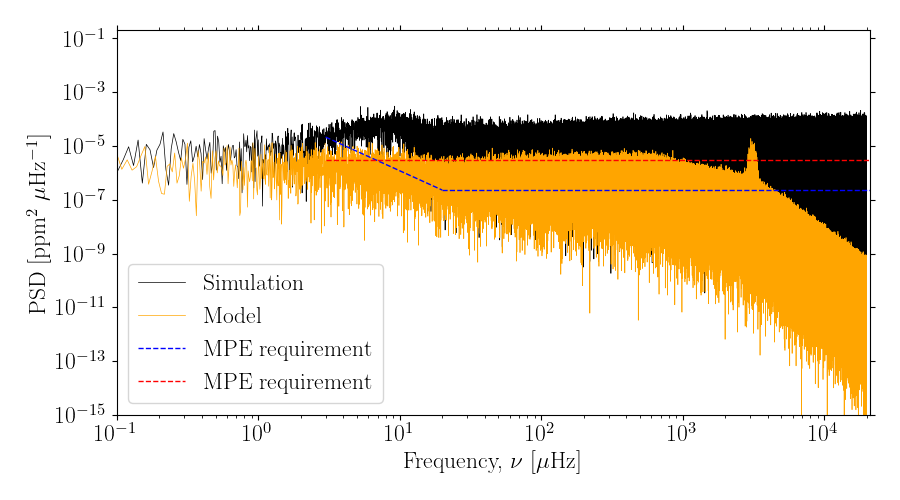

In [56]:
# Check PSD
fig, ax = pt.plotPeriodogram(df, dv)
ax.set_xlim(1e-1, 2.1e4)
ax.set_ylim(1e-15, 2e-1);

---
## Check LEISA proto-pipeline simulations (by James)
---

In [376]:
path = ut.getWorkDir('go_prems') / 'james'
flux_nostel = np.load(path / '000000605_norm_flux_nostel.npy')
flux_stel = np.load(path / '000000605_norm_flux_stel.npy')
flux_stel_pdc = np.load(path / '000000605_pdc_corrected_flux_stel.npy')

In [377]:
df_nostel   = pd.DataFrame(flux_nostel.T)
df_stel     = pd.DataFrame(flux_stel.T)
df_stel_pdc = pd.DataFrame(flux_stel_pdc.T)
names = [f'ncam{i}' for i in range(1,25)]
df_nostel   = df_nostel.set_axis(names, axis=1)
df_stel     = df_stel.set_axis(names, axis=1)
df_stel_pdc = df_stel_pdc.set_axis(names, axis=1)

In [378]:
time = np.arange(0, df_nostel.shape[0]) * 25

### Camera level

In [379]:
df1 = pd.DataFrame({'time':time, 'flux':df_stel['ncam1']+1})
dc1 = pd.DataFrame({'time':time, 'flux':df_stel_pdc['ncam1']+1})

<IPython.core.display.Javascript object>


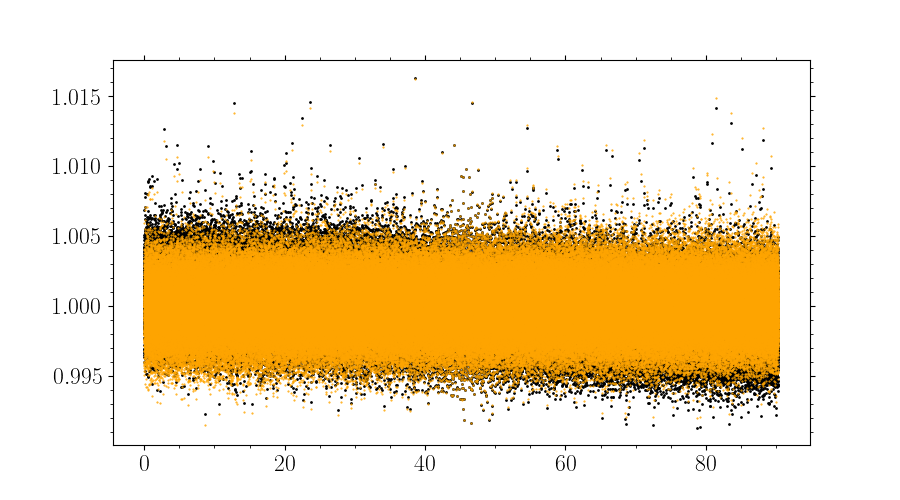

In [381]:
plt.figure(figsize=(9,5))
plt.plot(time/86400, df1.flux, 'k.', ms=2)
plt.plot(time/86400, dc1.flux, '.', c='orange', ms=1);

In [382]:
dt = 25e-6 # [Ms]
sigma = NSR_25s  # [ppm]
PSD_mean = dt*sigma**2 
ASD_mean = np.sqrt(np.pi/2*dt*sigma**2/2)
PSD_mean, ASD_mean

(128.38892533395276, 10.041734220634332)

<IPython.core.display.Javascript object>


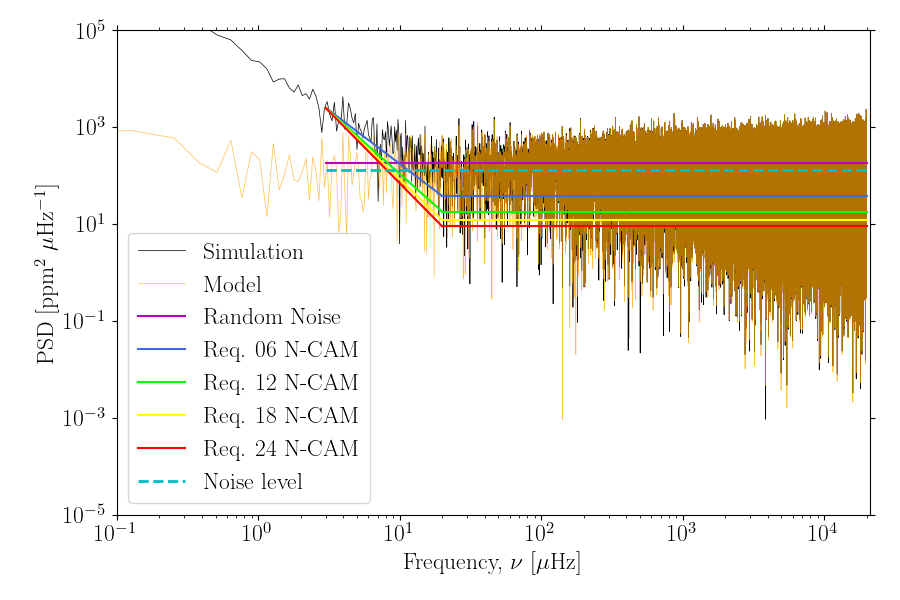

In [383]:
# Check PSD
fig, ax = pt.plotPeriodogram(df1, dc1, noise_level=PSD_mean)
ax.set_xlim(1e-1, 2.1e4)
ax.set_ylim(1e-5, 1e5);

### Mission level

<IPython.core.display.Javascript object>


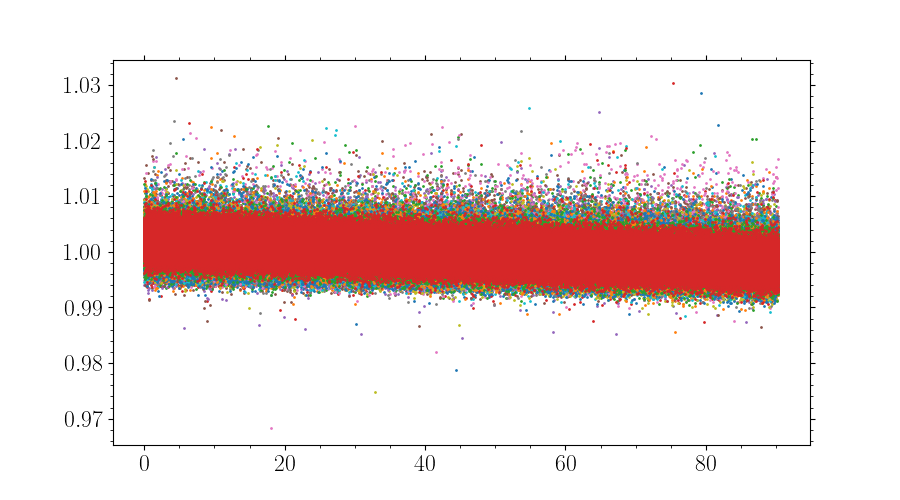

In [384]:
plt.figure(figsize=(9,5))
for n in range(1,25):
    dx = pd.DataFrame({'time':time, 'flux':df_stel[f'ncam{n}']+1})
    plt.plot(time/86400, dx.flux, '.', ms=2)

<IPython.core.display.Javascript object>


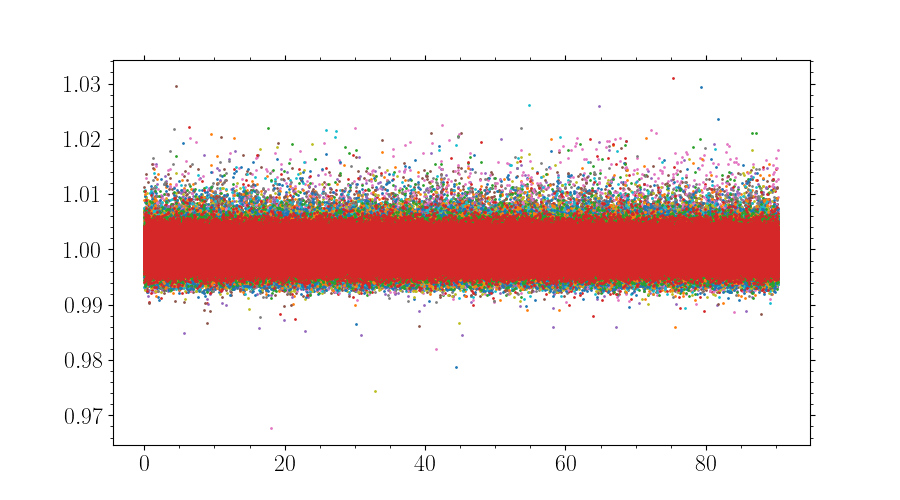

In [385]:
plt.figure(figsize=(9,5))
for n in range(1,25):
    dx = pd.DataFrame({'time':time, 'flux':df_stel_pdc[f'ncam{n}']+1})
    plt.plot(time/86400, dx.flux, '.', ms=2);

In [386]:
df = pd.DataFrame({'time':time, 'flux':df_stel[f'ncam1']+1})
for n in range(2,25):
    dx = pd.DataFrame({'time':time, 'flux':df_stel[f'ncam{n}']+1})
    df = pd.concat([df, dx])

In [387]:
df = df.sort_values(by="time")
df = df.groupby('time').mean().reset_index()
df

,time,flux
0,0,1.000038
1,25,1.001741
2,50,1.002779
3,75,1.002097
4,100,1.001597
...,...,...
312106,7802650,0.998461
312107,7802675,0.998594
312108,7802700,0.998127
312109,7802725,0.997914


In [388]:
# from scipy.stats import binned_statistic
# bins = round(df.shape[0] * 25 / 3600)
# f, t, _= binned_statistic(df.time, df.flux, statistic='median', bins=bins)
# t = t[:-1] + np.diff(t)[0] / 2
# df_1h = pd.DataFrame(np.transpose([t, f]), columns=['time', 'flux'])


In [402]:
dt = 25e-6 # [Ms]
sigma = df.flux.std()*1e6  # [ppm]
PSD_mean = dt*sigma**2 
ASD_mean = np.sqrt(np.pi/2*dt*sigma**2/2)
PSD_mean, ASD_mean

(19.290094157774888, 3.892352055413313)

<IPython.core.display.Javascript object>


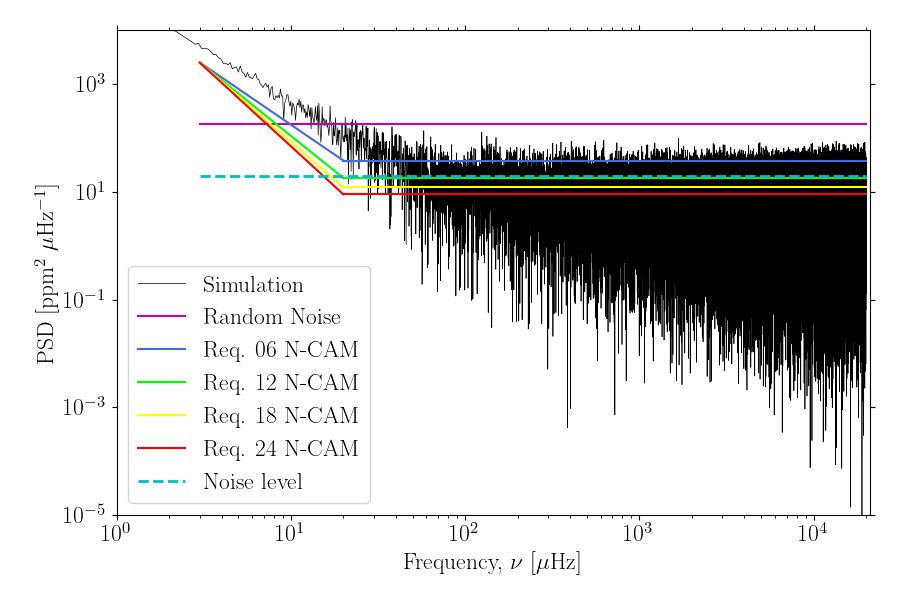

In [403]:
# Check PSD
fig, ax = pt.plotPeriodogram(df, noise_level=PSD_mean)
ax.set_xlim(1e0, 2.1e4)
ax.set_ylim(1e-5, 1e4);

In [394]:
data = pt.compute_double_sided_PSD(df.flux.to_numpy())

<IPython.core.display.Javascript object>


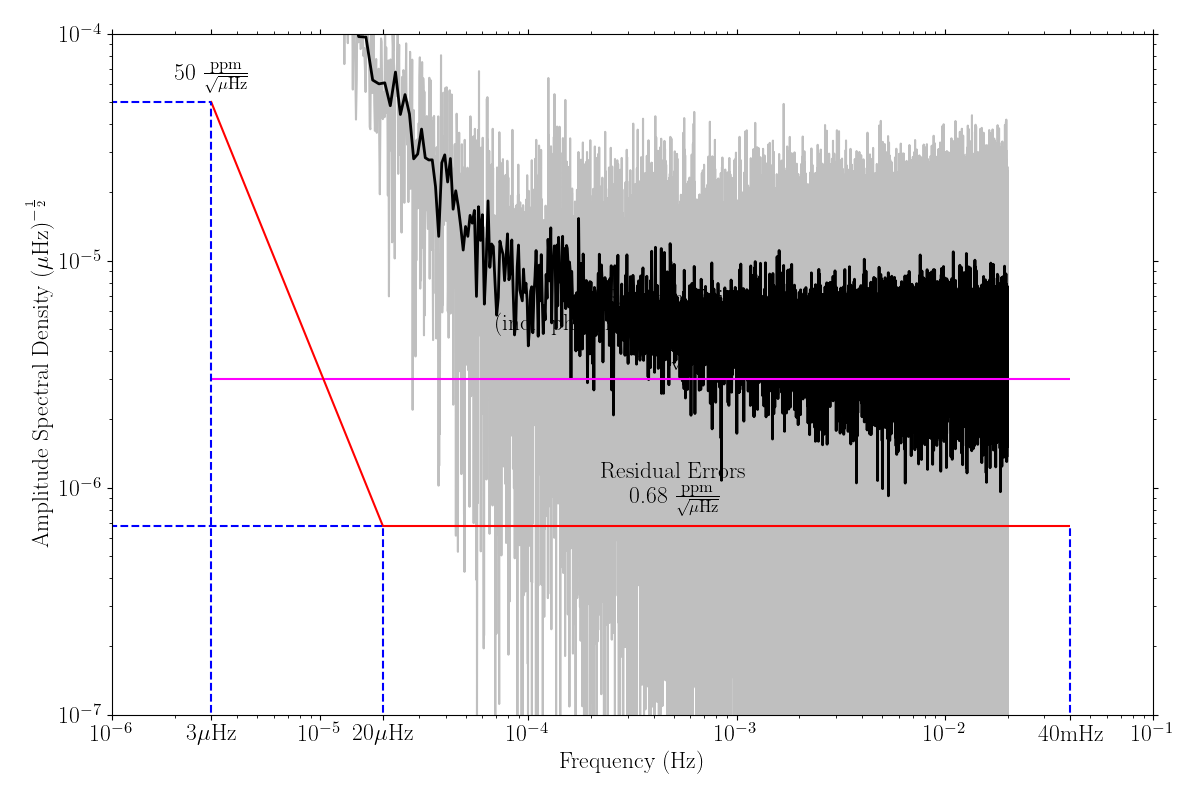

In [398]:
pt.create_performance_figure(data)